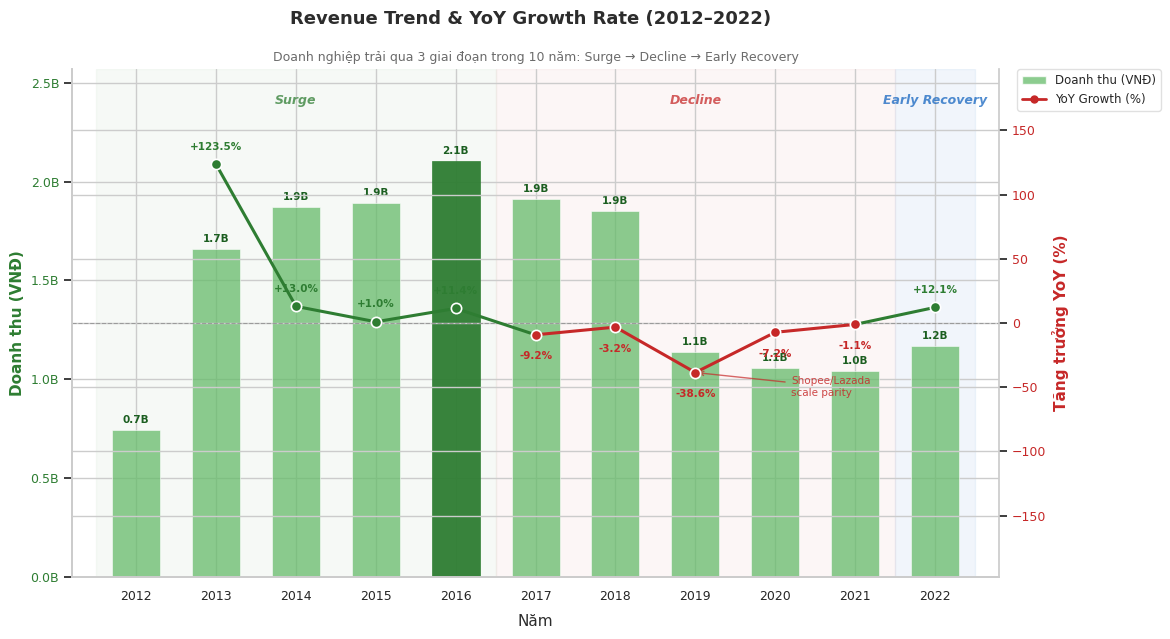

Saved: d:\BountyHunter\reports\figures\chart_1a.png


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

root_dir   = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
output_dir = os.path.join(root_dir, "reports", "figures")
os.makedirs(output_dir, exist_ok=True)

def generate_chart_1a():
    # ── Load ──────────────────────────────────────────────────────
    sales = pd.read_parquet(os.path.join(root_dir, "data", "processed", "sales.parquet"))

    yearly = (
        sales.groupby(sales["Date"].dt.year)["Revenue"]
        .sum()
        .reset_index()
        .rename(columns={"Date": "year"})
    )
    yearly["yoy_growth"] = yearly["Revenue"].pct_change() * 100

    # ── Style ─────────────────────────────────────────────────────
    sns.set_theme(style="whitegrid", font="DejaVu Sans")
    GRAY_DARK  = "#2C2C2C"
    GRAY_MID   = "#6B6B6B"
    GREEN_MAIN = "#2E7D32"
    GREEN_FILL = "#66BB6A"
    RED_LINE   = "#C62828"
    ANNOT_COL  = "#1B5E20"

    fig, ax1 = plt.subplots(figsize=(14, 6.5))
    fig.patch.set_facecolor("white")

    # ── Phase background shading ──────────────────────────────────
    ax1.axvspan(2011.5, 2016.5, alpha=0.04, color=GREEN_MAIN, zorder=0)
    ax1.axvspan(2016.5, 2021.5, alpha=0.04, color=RED_LINE,   zorder=0)
    ax1.axvspan(2021.5, 2022.5, alpha=0.06, color="#1565C0",  zorder=0)

    phase_y = yearly["Revenue"].max() * 1.13
    for x, label, color in [
        (2014,   "Surge",    GREEN_MAIN),
        (2019,   "Decline",  RED_LINE),
        (2022,   "Early Recovery", "#1565C0"),
    ]:
        ax1.text(x, phase_y, label,
                 ha="center", va="bottom", fontsize=9,
                 color=color, fontstyle="italic",
                 fontweight="bold", alpha=0.75,
                 clip_on=False)

    # ── Bar chart — Revenue ───────────────────────────────────────
    bars = ax1.bar(
        yearly["year"], yearly["Revenue"],
        color=GREEN_FILL, alpha=0.75,
        width=0.6, zorder=2,
        edgecolor="white", linewidth=0.5
    )

    # highlight peak
    peak_idx = yearly["Revenue"].idxmax()
    bars[peak_idx].set_color(GREEN_MAIN)
    bars[peak_idx].set_alpha(0.95)

    # label revenue
    for bar, (_, row) in zip(bars, yearly.iterrows()):
        val = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            val + yearly["Revenue"].max() * 0.012,
            f"{val/1e9:.1f}B",
            ha="center", va="bottom",
            fontsize=7.5, color=ANNOT_COL, fontweight="bold"
        )

    ax1.set_xlabel("Năm", fontsize=11, color=GRAY_DARK, labelpad=8)
    ax1.set_ylabel("Doanh thu (VNĐ)", fontsize=11,
                   color=GREEN_MAIN, fontweight="bold")
    ax1.tick_params(axis="y", labelcolor=GREEN_MAIN, labelsize=9)
    ax1.tick_params(axis="x", labelsize=9, color=GRAY_MID)
    ax1.set_xticks(yearly["year"])
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B")
    )
    ax1.set_ylim(0, yearly["Revenue"].max() * 1.22)
    ax1.set_xlim(2011.2, 2022.8)
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.spines["left"].set_color("#CCCCCC")
    ax1.spines["bottom"].set_color("#CCCCCC")

    # ── Line chart — YoY growth ───────────────────────────────────
    ax2 = ax1.twinx()
    yoy_data = yearly.dropna(subset=["yoy_growth"])

    for i in range(len(yoy_data) - 1):
        x0 = yoy_data["year"].iloc[i]
        x1 = yoy_data["year"].iloc[i + 1]
        y0 = yoy_data["yoy_growth"].iloc[i]
        y1 = yoy_data["yoy_growth"].iloc[i + 1]
        seg_color = GREEN_MAIN if (y0 + y1) / 2 >= 0 else RED_LINE
        ax2.plot([x0, x1], [y0, y1],
                 color=seg_color, linewidth=2.2,
                 solid_capstyle="round", zorder=3)

    for _, row in yoy_data.iterrows():
        dot_color = GREEN_MAIN if row["yoy_growth"] >= 0 else RED_LINE
        ax2.scatter(row["year"], row["yoy_growth"],
                    color=dot_color, s=55, zorder=4,
                    edgecolors="white", linewidths=1.2)

    for _, row in yoy_data.iterrows():
        offset = 9 if row["yoy_growth"] >= 0 else -12
        va     = "bottom" if row["yoy_growth"] >= 0 else "top"
        color  = GREEN_MAIN if row["yoy_growth"] >= 0 else RED_LINE
        ax2.annotate(
            f"{row['yoy_growth']:+.1f}%",
            (row["year"], row["yoy_growth"]),
            xytext=(0, offset), textcoords="offset points",
            ha="center", va=va,
            fontsize=7.5, color=color, fontweight="bold"
        )

    ax2.axhline(0, color=GRAY_MID, linewidth=0.8,
                linestyle="--", alpha=0.5, zorder=1)

    ax2.set_ylabel("Tăng trưởng YoY (%)", fontsize=11,
                   color=RED_LINE, fontweight="bold")
    ax2.tick_params(axis="y", labelcolor=RED_LINE, labelsize=9)
    ax2.spines[["top"]].set_visible(False)
    ax2.spines["right"].set_color("#CCCCCC")

    yoy_abs = yoy_data["yoy_growth"].abs().max()
    ax2.set_ylim(-yoy_abs * 1.6, yoy_abs * 1.6)

    # ── Annotation ────────────────────────────────────────────────
    row_2019 = yearly[yearly["year"] == 2019].iloc[0]
    ax2.annotate(
        "Shopee/Lazada\nscale parity",
        xy=(2019, row_2019["yoy_growth"]),
        xytext=(2020.2, row_2019["yoy_growth"] - 18),
        fontsize=7.5, color=RED_LINE, alpha=0.85,
        arrowprops=dict(arrowstyle="->", color=RED_LINE,
                        lw=1.0, alpha=0.7),
        ha="left"
    )

    # ── Legend (FIX) ─────────────────────────────────────────────
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    legend_items = [
        Patch(facecolor=GREEN_FILL, alpha=0.75, label="Doanh thu (VNĐ)"),
        Line2D([0], [0], color=RED_LINE, linewidth=2,
               marker="o", markersize=5, label="YoY Growth (%)"),
    ]

    ax1.legend(
        handles=legend_items,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        fontsize=8.5,
        framealpha=0.9,
        edgecolor="#DDDDDD",
        fancybox=True
    )

    # ── Title ─────────────────────────────────────────────────────
    fig.suptitle(
        "Revenue Trend & YoY Growth Rate (2012–2022)",
        fontsize=13,
        fontweight="bold",
        color=GRAY_DARK,
        x=0.385,          # căn giữa ngang
        y=0.98,         # hạ xuống chút cho cân
        ha="center"
)
    ax1.set_title(
        "Doanh nghiệp trải qua 3 giai đoạn trong 10 năm: "
        "Surge → Decline → Early Recovery",
        fontsize=9, color=GRAY_MID, pad=6
    )

    # ── Save ──────────────────────────────────────────────────────
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # 👈 QUAN TRỌNG
    save_path = os.path.join(output_dir, "chart_1a.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor="white")
    plt.show()

    print(f"Saved: {save_path}")


generate_chart_1a()

In [3]:
import pandas as pd
import numpy as np

def analyze_revenue_concentration_and_churn(orders, order_items):
    """
    Phân tích:
    1. Revenue concentration (top 10% customers)
    2. So sánh 2018 vs 2019
    3. Churn của nhóm top customers
    
    Params:
        orders: DataFrame (order_id, customer_id, order_date)
        order_items: DataFrame (order_id, quantity, unit_price)
    
    Returns:
        dict kết quả + in insight
    """

    # ─────────────────────────────
    # 1. Tạo revenue per order
    # ─────────────────────────────
    order_items["revenue_line"] = order_items["quantity"] * order_items["unit_price"]

    order_revenue = (
        order_items.groupby("order_id")["revenue_line"]
        .sum()
        .reset_index()
    )

    df = orders.merge(order_revenue, on="order_id", how="left")
    df["year"] = df["order_date"].dt.year

    # ─────────────────────────────
    # 2. Revenue per customer per year
    # ─────────────────────────────
    cust_year = (
        df.groupby(["year", "customer_id"])["revenue_line"]
        .sum()
        .reset_index()
    )

    results = {}

    top_customers_2018 = None

    for year in [2018, 2019]:
        data = cust_year[cust_year["year"] == year].copy()

        # sort giảm dần
        data = data.sort_values("revenue_line", ascending=False)

        # tổng revenue
        total_revenue = data["revenue_line"].sum()

        # top 10%
        n_top = int(len(data) * 0.1)
        top_group = data.head(n_top)

        top_share = top_group["revenue_line"].sum() / total_revenue

        results[year] = {
            "total_revenue": total_revenue,
            "top_10pct_share": top_share,
            "n_customers": len(data)
        }

        print(f"\n📊 Year {year}")
        print(f"Total revenue: {total_revenue:,.0f}")
        print(f"Top 10% contribution: {top_share*100:.2f}%")

        if year == 2018:
            top_customers_2018 = set(top_group["customer_id"])

    # ─────────────────────────────
    # 3. Churn analysis
    # ─────────────────────────────
    customers_2019 = set(cust_year[cust_year["year"] == 2019]["customer_id"])

    churned = top_customers_2018 - customers_2019
    churn_rate = len(churned) / len(top_customers_2018)

    print("\n🚨 CHURN ANALYSIS (Top 10% from 2018)")
    print(f"Top customers 2018: {len(top_customers_2018)}")
    print(f"Churned in 2019: {len(churned)}")
    print(f"Churn rate: {churn_rate*100:.2f}%")

    # ─────────────────────────────
    # 4. Insight logic
    # ─────────────────────────────
    top_share_2018 = results[2018]["top_10pct_share"]

    if top_share_2018 > 0.6 and churn_rate > 0.3:
        print("\n🔥 INSIGHT:")
        print("Revenue phụ thuộc mạnh vào top 10% khách hàng.")
        print("Nhóm này churn cao → nguyên nhân trực tiếp gây giảm revenue.")
    else:
        print("\nℹ️ INSIGHT:")
        print("Không có dấu hiệu phụ thuộc quá mức hoặc churn chưa đủ lớn.")

    return {
        "yearly_stats": results,
        "churn_rate_top_2018": churn_rate,
        "churned_customers": churned
    }


orders = pd.read_parquet("../data/processed/orders.parquet")
order_items = pd.read_parquet("../data/processed/order_items.parquet")

result = analyze_revenue_concentration_and_churn(orders, order_items)


📊 Year 2018
Total revenue: 1,850,122,456
Top 10% contribution: 32.24%

📊 Year 2019
Total revenue: 1,136,801,442
Top 10% contribution: 31.05%

🚨 CHURN ANALYSIS (Top 10% from 2018)
Top customers 2018: 3792
Churned in 2019: 1194
Churn rate: 31.49%

ℹ️ INSIGHT:
Không có dấu hiệu phụ thuộc quá mức hoặc churn chưa đủ lớn.


In [14]:
orders = pd.read_parquet("../data/processed/orders.parquet")
orders["year"] = orders["order_date"].dt.year

valid_statuses = ["delivered", "shipped", "paid"]

for yr in [2017, 2018, 2019, 2020]:
    df = orders[
        (orders["year"] == yr) &
        (orders["order_status"].isin(valid_statuses))
    ]
    n_customers = df["customer_id"].nunique()
    n_orders    = df["order_id"].nunique()
    print(f"{yr}  customers={n_customers:,}  orders={n_orders:,}  "
          f"orders/customer={n_orders/n_customers:.2f}")

2017  customers=35,979  orders=64,142  orders/customer=1.78
2018  customers=34,323  orders=58,539  orders/customer=1.71
2019  customers=24,235  orders=34,990  orders/customer=1.44
2020  customers=21,551  orders=29,327  orders/customer=1.36


In [7]:
import pandas as pd

def analyze_promo_penetration(orders, order_items):
    """
    Promo penetration = % don hang co promo hop le (dung campaign window)
    Input:
        orders      : pd.DataFrame da load tu parquet (co order_date datetime)
        order_items : pd.DataFrame da load tu parquet
    Output:
        yearly      : pd.DataFrame yearly stats
    """

    # ── 1. Load promotions ────────────────────────────────────────
    promotions = pd.read_parquet("../data/processed/promotions.parquet")

    # ── 2. Filter don hop le ──────────────────────────────────────
    valid_statuses = ["delivered", "shipped", "paid"]
    orders_clean = orders[orders["order_status"].isin(valid_statuses)].copy()

    # ── 3. Merge order_items ──────────────────────────────────────
    df = orders_clean[["order_id", "order_date"]].merge(
        order_items[["order_id", "promo_id"]],
        on="order_id",
        how="left"
    )

    # ── 4. Join promotions de lay date window ─────────────────────
    df = df.merge(
        promotions[["promo_id", "start_date", "end_date"]],
        on="promo_id",
        how="left"
    )

    # ── 5. Validate promo: promo_id khong null VA trong date window
    df["valid_promo"] = (
        df["promo_id"].notna() &
        (df["order_date"] >= df["start_date"]) &
        (df["order_date"] <= df["end_date"])
    ).astype(int)

    # ── 6. Order-level (tranh double count khi 1 order nhieu line) -
    order_level = (
        df.groupby("order_id")
        .agg(
            order_date=("order_date", "first"),
            has_promo =("valid_promo", "max")
        )
        .reset_index()
    )
    order_level["year"] = order_level["order_date"].dt.year

    # ── 7. Yearly aggregation ─────────────────────────────────────
    yearly = (
        order_level.groupby("year")
        .agg(
            total_orders=("order_id",  "count"),
            promo_orders=("has_promo", "sum")
        )
        .reset_index()
    )
    yearly["promo_penetration_pct"] = (
        yearly["promo_orders"] / yearly["total_orders"] * 100
    ).round(2)

    # ── 8. Print full table ───────────────────────────────────────
    print("=" * 55)
    print("  PROMO PENETRATION BY YEAR")
    print("=" * 55)
    print(f"  {'Year':>4}  {'Total':>8}  {'Promo':>8}  {'Pct':>7}")
    print("  " + "-" * 38)
    for _, row in yearly.iterrows():
        print(f"  {int(row['year']):>4}  "
              f"{int(row['total_orders']):>8,}  "
              f"{int(row['promo_orders']):>8,}  "
              f"{row['promo_penetration_pct']:>6.1f}%")

    # ── 9. YoY change ─────────────────────────────────────────────
    yearly["pct_change"] = yearly["promo_penetration_pct"].diff()

    print("\n  YoY CHANGE IN PENETRATION")
    print("  " + "-" * 38)
    for _, row in yearly.dropna(subset=["pct_change"]).iterrows():
        arrow = "↑" if row["pct_change"] > 0 else "↓"
        print(f"  {int(row['year']-1)}->{int(row['year'])}  "
              f"{arrow} {abs(row['pct_change']):.1f}pp")

    # ── 10. Kiem tra gia thuyet 2015-2016 ─────────────────────────
    sub = yearly[yearly["year"].isin([2015, 2016])]
    if len(sub) == 2:
        p15 = sub[sub["year"] == 2015]["promo_penetration_pct"].values[0]
        p16 = sub[sub["year"] == 2016]["promo_penetration_pct"].values[0]
        change  = p16 - p15
        growth  = (change / p15 * 100) if p15 != 0 else None

        print(f"\n  FOCUS: 2015 → 2016")
        print(f"  2015: {p15:.1f}%  |  2016: {p16:.1f}%")
        print(f"  Absolute change : {change:+.1f}pp")
        if growth is not None:
            print(f"  Relative growth : {growth:+.1f}%")

        print("\n  INSIGHT:")
        if growth is not None and growth > 30:
            print("  WARN: Promo tang manh → doanh thu 2016 co the dang")
            print("        duoc 'mua' bang discount, can kiem tra margin")
        elif growth is not None and 0 < growth <= 30:
            print("  INFO: Promo tang nhe → gia thuyet chua du manh,")
            print("        nen kiem tra them margin theo nam")
        elif growth is not None and growth <= 0:
            print("  OK: Promo khong tang → doanh thu 2016 khong den")
            print("     tu viec day manh discount")

    print("=" * 55)
    return yearly


# ── CHAY ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    orders      = pd.read_parquet("../data/processed/orders.parquet")
    order_items = pd.read_parquet("../data/processed/order_items.parquet")

    yearly = analyze_promo_penetration(orders, order_items)

  PROMO PENETRATION BY YEAR
  Year     Total     Promo      Pct
  --------------------------------------
  2012    27,018         0     0.0%
  2013    64,625    29,853    46.2%
  2014    68,032    24,906    36.6%
  2015    69,514    32,038    46.1%
  2016    69,278    23,906    34.5%
  2017    64,142    28,327    44.2%
  2018    58,539    19,477    33.3%
  2019    34,990    15,665    44.8%
  2020    29,327    10,766    36.7%
  2021    28,758    12,707    44.2%
  2022    29,843    10,954    36.7%

  YoY CHANGE IN PENETRATION
  --------------------------------------
  2012->2013  ↑ 46.2pp
  2013->2014  ↓ 9.6pp
  2014->2015  ↑ 9.5pp
  2015->2016  ↓ 11.6pp
  2016->2017  ↑ 9.6pp
  2017->2018  ↓ 10.9pp
  2018->2019  ↑ 11.5pp
  2019->2020  ↓ 8.1pp
  2020->2021  ↑ 7.5pp
  2021->2022  ↓ 7.5pp

  FOCUS: 2015 → 2016
  2015: 46.1%  |  2016: 34.5%
  Absolute change : -11.6pp
  Relative growth : -25.1%

  INSIGHT:
  OK: Promo khong tang → doanh thu 2016 khong den
     tu viec day manh discount


In [13]:
def analyze_recovery_quality(orders, order_items):

    # filter status hop le
    valid_statuses = ["delivered", "shipped", "paid"]
    orders = orders[orders["order_status"].isin(valid_statuses)].copy()

    # revenue per order
    oi = order_items.copy()
    oi["line_revenue"] = oi["quantity"] * oi["unit_price"]
    order_rev = (
        oi.groupby("order_id")["line_revenue"]
        .sum()
        .reset_index(name="order_revenue")
    )

    # merge
    df = (
        orders[["order_id", "customer_id", "order_date"]]
        .merge(order_rev, on="order_id", how="left")
    )
    df["order_revenue"] = df["order_revenue"].fillna(0)
    df["month"] = df["order_date"].dt.to_period("M")

    # monthly metrics
    monthly = (
        df.groupby("month")
        .agg(
            total_orders    =("order_id",       "count"),
            active_customers=("customer_id",    "nunique"),
            total_revenue   =("order_revenue",  "sum")
        )
        .reset_index()
    )
    monthly["orders_per_customer"] = (
        monthly["total_orders"] / monthly["active_customers"]
    )
    monthly["AOV"]  = monthly["total_revenue"] / monthly["total_orders"]
    monthly["year"] = monthly["month"].dt.year

    # yearly summary
    summary = (
        monthly.groupby("year")
        .agg(
            active_customers   =("active_customers",    "mean"),
            orders_per_customer=("orders_per_customer", "mean"),
            AOV                =("AOV",                 "mean")
        )
        .reset_index()
    )

    # compare 2021 vs 2022
    sub = summary[summary["year"].isin([2021, 2022])]
    print("\n📊 Yearly Summary (avg monthly):")
    print(sub.to_string(index=False))

    if len(sub) == 2:
        y21 = sub[sub["year"] == 2021].iloc[0]
        y22 = sub[sub["year"] == 2022].iloc[0]
        ac_growth  = (y22["active_customers"]    - y21["active_customers"])    / y21["active_customers"]
        opc_growth = (y22["orders_per_customer"] - y21["orders_per_customer"]) / y21["orders_per_customer"]
        aov_growth = (y22["AOV"] - y21["AOV"]) / y21["AOV"]

        print(f"\n🔍 Growth 2021 → 2022:")
        print(f"  Active customers  : {ac_growth*100:+.1f}%")
        print(f"  Orders/customer   : {opc_growth*100:+.1f}%")
        print(f"  AOV               : {aov_growth*100:+.1f}%")

        # Thay doan insight cu bang cai nay
        OPC_THRESHOLD = 0.02  # can tang it nhat 2% moi tinh la co y nghia

        print("\n💡 Insight:")
        if ac_growth > 0 and opc_growth >= OPC_THRESHOLD:
             print("  ✅ Recovery REAL → khach quay lai + mua nhieu hon")
        elif aov_growth > 0 and opc_growth < OPC_THRESHOLD:
            print("  ⚠️  Revenue tang chu yeu do AOV (+{:.1f}%) va khach moi (+{:.1f}%)".format(
          aov_growth*100, ac_growth*100))
            print("      Orders/customer gần như đứng yên ({:+.1f}%) → recovery mong manh".format(
          opc_growth*100))
        else:
            print("  ❌ Khong co dau hieu phuc hoi ro rang")

    return monthly, summary

orders      = pd.read_parquet("../data/processed/orders.parquet")
order_items = pd.read_parquet("../data/processed/order_items.parquet")

monthly, summary = analyze_recovery_quality(orders, order_items)


📊 Yearly Summary (avg monthly):
 year  active_customers  orders_per_customer          AOV
 2021       2289.083333             1.044734 30402.143702
 2022       2372.583333             1.045862 32409.692053

🔍 Growth 2021 → 2022:
  Active customers  : +3.6%
  Orders/customer   : +0.1%
  AOV               : +6.6%

💡 Insight:
  ⚠️  Revenue tang chu yeu do AOV (+6.6%) va khach moi (+3.6%)
      Orders/customer gần như đứng yên (+0.1%) → recovery mong manh
